# European Defence Investment Monitor
### NATO Defence Expenditure Analysis | 2014–2026

This notebook builds a reproducible data pipeline to analyse defence expenditure trends among European NATO Allies.

The analysis covers:
- Defence expenditure as a share of GDP
- Annual real expenditure growth
- Equipment expenditure
- Personnel expenditure
- Infrastructure expenditure
- Other defence expenditure
- Historical transformation (2014–2024)
- Estimated outlook to 2026

**Primary source:** NATO Defence Expenditure data.

> Note: Figures for 2025 and 2026 are NATO estimates and are treated separately from observed historical data.

## 1. Environment Setup

Import the Python libraries required for data extraction, transformation, validation and exploratory analysis.

In [1576]:
import sys
print(sys.version)
print(sys.executable)

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
c:\Users\cl_am\AppData\Local\Programs\Python\Python314\python.exe


## 2. Data Source and Initial Inspection

The original NATO Excel workbook is kept unchanged in the `data/raw` directory.

Before transforming the data, the workbook structure and available sheets are inspected to understand how the information is organised.

In [1577]:
import pandas as pd

file_path = "../data/raw/nato_defence_expenditure_2026.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Table 1',
 'Table 2',
 'Table 3',
 'Table 4',
 'Table 5',
 'Table 6',
 'Table 7',
 'Table 8a',
 'Table 8b']

In [1578]:
import os

print(os.getcwd())

c:\Users\cl_am\OneDrive\Desktop\European-Defence-Analytics\notebooks


## 3. Defence Expenditure Data Extraction

NATO Table 3 contains two different indicators within the same worksheet:

1. Core defence expenditure as a share of GDP.
2. Annual real change in defence expenditure.

The worksheet is initially imported without predefined headers in order to identify titles, year rows, country observations and notes before extracting each data block.

In [1579]:
df_raw = pd.read_excel(
    file_path,
    sheet_name="Table 3",
    header=None
)

df_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Table 3: Core defence expenditure as a share o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Based on 2021 prices,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Share of real GDP (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2014.00,2015.00,2016.00,2017.00,2018.00,2019.00,2020.00,2021.00,2022.00,2023.00,2024.00,2025e,2026e
4,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
5,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
6,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
7,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
8,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03
9,Czechia,0.94,1.02,0.94,1.02,1.09,1.16,1.27,1.35,1.29,1.31,1.99,1.86,2.01


In [1580]:
df_raw.shape

(75, 14)

In [1581]:
df_raw.tail(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
45,Czechia,-5.03,13.86,-4.94,13.90,10.06,10.20,3.91,9.85,-1.36,1.96,52.83,-4.04,10.53
46,Denmark,-4.82,-1.00,6.43,2.07,14.65,2.99,3.86,0.68,5.78,47.96,17.78,47.08,9.44
47,Estonia,3.78,7.14,5.00,2.54,3.69,5.15,10.29,-3.70,5.13,35.22,10.71,19.31,32.41
48,Finland,-6.05,0.40,0.72,0.53,1.40,6.00,2.87,-6.16,20.59,24.33,-0.20,30.7,-3.11
49,France,-1.20,-1.00,1.39,1.67,3.49,2.17,1.08,2.41,0.86,2.08,9.63,1.39,9.07
50,Germany,-1.42,1.54,3.43,5.54,2.70,9.22,7.61,-0.65,4.42,8.77,24.26,11.26,22.29
51,Greece,0.42,3.60,3.38,0.23,8.62,-1.94,7.73,38.64,12.03,-27.28,2.20,2.83,33.17
52,Hungary,-5.22,9.34,13.19,24.19,-11.19,39.22,25.81,-19.25,45.65,8.02,11.25,-6.27,3.1
53,Italy,-9.81,-5.83,12.05,3.75,2.91,-4.05,23.33,4.88,3.22,-1.48,4.65,38.5,1.01
54,Latvia,2.64,14.35,42.65,14.88,34.73,-1.31,2.77,3.57,6.49,28.85,11.71,14.32,36.81


In [1582]:
pd.set_option("display.max_columns", None)

In [1583]:
df_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Table 3: Core defence expenditure as a share o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Based on 2021 prices,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Share of real GDP (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2014.00,2015.00,2016.00,2017.00,2018.00,2019.00,2020.00,2021.00,2022.00,2023.00,2024.00,2025e,2026e
4,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
5,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
6,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
7,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
8,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03
9,Czechia,0.94,1.02,0.94,1.02,1.09,1.16,1.27,1.35,1.29,1.31,1.99,1.86,2.01


### 3.1 Extracting Individual Metrics

The two indicators contained in Table 3 are extracted into separate DataFrames.

Headers are standardised and non-data rows such as titles, blank rows and methodological notes are excluded.

In [1584]:
df_gdp_share = df_raw.iloc[4:37].copy()

df_gdp_share.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
4,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
5,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
6,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
7,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
8,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03


In [1585]:
df_gdp_share.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_gdp_share.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
4,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
5,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
6,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
7,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
8,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03


In [1586]:
df_gdp_share.reset_index(drop=True, inplace=True)
df_gdp_share.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
0,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
1,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
2,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
3,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
4,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03


In [1587]:
df_gdp_share.tail()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
28,Türkiye,1.44,1.38,1.45,1.50,1.79,1.82,1.83,1.57,1.33,1.45,2.08,2.33,2.85
29,United Kingdom,2.13,2.02,2.07,2.06,2.08,2.06,2.33,2.25,2.22,2.22,2.28,2.32,2.56
30,United States,3.71,3.51,3.49,3.28,3.25,3.49,3.61,3.47,3.20,3.15,3.30,3.17,3.17
31,NATO Europe and Canada,1.40,1.40,1.41,1.45,1.48,1.51,1.69,1.62,1.62,1.71,1.96,2.31,2.53
32,NATO Total,2.56,2.46,2.46,2.37,2.38,2.51,2.68,2.58,2.43,2.45,2.65,2.75,2.86


In [1588]:
df_real_change = df_raw.iloc[40:73].copy()

In [1589]:
df_real_change.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

In [1590]:
df_real_change.reset_index(drop=True, inplace=True)
df_real_change.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
0,Albania,-2.63,-11.95,-1.67,3.03,8.86,12.95,-1.53,4.48,1.97,11.77,9.01,13.21,50.03
1,Belgium,-2.11,-4.25,-0.34,0.21,2.52,1.82,7.96,10.14,16.36,0.93,11.17,58.52,0.79
2,Bulgaria,-9.08,-1.56,2.80,0.96,21.79,124.85,-51.20,2.65,9.32,24.81,2.66,13.65,6.8
3,Canada,4.95,20.09,-2.48,27.76,-7.18,1.61,3.37,-5.18,-2.29,12.15,11.37,46.32,5.95
4,Croatia,25.94,-1.04,-5.99,6.15,-2.82,7.20,-2.99,30.88,-1.90,-5.24,16.56,15.6,1.01


In [1591]:
print("GDP Share:")
print(df_gdp_share.shape)

print("\nAnnual Real Change:")
print(df_real_change.shape)

GDP Share:
(33, 14)

Annual Real Change:
(33, 14)


In [1592]:
df_gdp_share

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
0,Albania,1.34,1.15,1.09,1.09,1.14,1.27,1.29,1.24,1.20,1.29,1.35,1.48,2.15
1,Belgium,0.97,0.91,0.90,0.89,0.89,0.89,1.01,1.04,1.17,1.16,1.27,2,2
2,Bulgaria,1.31,1.25,1.24,1.22,1.45,3.15,1.59,1.51,1.59,1.95,1.93,2.13,2.22
3,Canada,1.01,1.20,1.16,1.44,1.30,1.29,1.41,1.26,1.18,1.29,1.41,2.03,2.13
4,Croatia,1.81,1.75,1.59,1.63,1.54,1.60,1.70,1.97,1.80,1.65,1.85,2.07,2.03
5,Czechia,0.94,1.02,0.94,1.02,1.09,1.16,1.27,1.35,1.29,1.31,1.99,1.86,2.01
6,Denmark,1.15,1.11,1.15,1.14,1.28,1.30,1.37,1.30,1.37,2.01,2.29,3.27,3.49
7,Estonia,1.90,1.99,2.03,1.97,1.97,2.00,2.26,2.02,2.14,2.98,3.31,3.93,5.1
8,Finland,1.46,1.46,1.43,1.39,1.40,1.46,1.54,1.41,1.69,2.12,2.11,2.75,2.65
9,France,1.82,1.78,1.79,1.78,1.81,1.82,1.99,1.90,1.87,1.88,2.04,2.04,2.22


## 4. Reshaping the Data: Wide to Long Format

The original NATO tables store years as separate columns.

For analytical purposes, the data are converted from wide format to long format, producing one observation per country and year.

This structure is better suited for:
- Time-series analysis
- Dataset merging
- Power BI
- Filtering and aggregation

In [1593]:
df_gdp_long = df_gdp_share.melt(
    id_vars="Country",
    var_name="Year",
    value_name="GDP_Share"
)

df_gdp_long.head(15)

,Country,Year,GDP_Share
0,Albania,2014,1.34
1,Belgium,2014,0.97
2,Bulgaria,2014,1.31
3,Canada,2014,1.01
4,Croatia,2014,1.81
5,Czechia,2014,0.94
6,Denmark,2014,1.15
7,Estonia,2014,1.9
8,Finland,2014,1.46
9,France,2014,1.82


### 4.1 Identifying NATO Estimates

NATO labels 2025 and 2026 values with an `e` to indicate estimates.

Instead of removing this information, an `Estimated` boolean variable is created before converting the year into a numeric field.

This preserves the distinction between observed and estimated data throughout the analysis.

In [1594]:
df_gdp_long["Estimated"] = (
    df_gdp_long["Year"]
    .astype(str)
    .str.endswith("e")
)

In [1595]:
df_gdp_long.tail()

,Country,Year,GDP_Share,Estimated
424,Türkiye,2026e,2.85,True
425,United Kingdom,2026e,2.56,True
426,United States,2026e,3.17,True
427,NATO Europe and Canada,2026e,2.53,True
428,NATO Total,2026e,2.86,True


In [1596]:
df_gdp_long["Year"] = (
    df_gdp_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

In [1597]:
df_gdp_long.tail()

,Country,Year,GDP_Share,Estimated
424,Türkiye,2026,2.85,True
425,United Kingdom,2026,2.56,True
426,United States,2026,3.17,True
427,NATO Europe and Canada,2026,2.53,True
428,NATO Total,2026,2.86,True


In [1598]:
df_change_long = df_real_change.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Real_Annual_Change"
)

In [1599]:
df_change_long["Estimated"] = (
    df_change_long["Year"]
    .astype(str)
    .str.endswith("e")
)

In [1600]:
df_change_long["Year"] = (
    df_change_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

In [1601]:
df_change_long.head()

,Country,Year,Real_Annual_Change,Estimated
0,Albania,2014,-2.63,False
1,Belgium,2014,-2.11,False
2,Bulgaria,2014,-9.08,False
3,Canada,2014,4.95,False
4,Croatia,2014,25.94,False


In [1602]:
print("GDP share wide:", df_gdp_share.shape)
print("GDP share long:", df_gdp_long.shape)

print()

print("Real change wide:", df_real_change.shape)
print("Real change long:", df_change_long.shape)

GDP share wide: (33, 14)
GDP share long: (429, 4)

Real change wide: (33, 14)
Real change long: (429, 4)


## 5. Building the Initial Analytical Dataset

The GDP expenditure indicator and annual real change indicator are merged using `Country` and `Year` as the composite key.

This produces a single longitudinal dataset containing both expenditure intensity and annual expenditure dynamics.

In [1603]:
df_defence = pd.merge(
    df_gdp_long,
    df_change_long[["Country", "Year", "Real_Annual_Change"]],
    on=["Country", "Year"],
    how="left"
)
df_defence.head()

,Country,Year,GDP_Share,Estimated,Real_Annual_Change
0,Albania,2014,1.34,False,-2.63
1,Belgium,2014,0.97,False,-2.11
2,Bulgaria,2014,1.31,False,-9.08
3,Canada,2014,1.01,False,4.95
4,Croatia,2014,1.81,False,25.94


Pruebas para comprobar que este bien el dataset

In [1604]:
df_defence[df_defence["Country"] == "Spain"]

,Country,Year,GDP_Share,Estimated,Real_Annual_Change
26,Spain,2014,0.92,False,0.36
59,Spain,2015,0.92,False,4.6
92,Spain,2016,0.8,False,-10.19
125,Spain,2017,0.9,False,15.35
158,Spain,2018,0.92,False,4.87
191,Spain,2019,0.9,False,-0.45
224,Spain,2020,1.0,False,-1.48
257,Spain,2021,1.02,False,8.84
290,Spain,2022,1.13,False,18.84
323,Spain,2023,1.17,False,5.23


In [1605]:
df_defence[
    (df_defence["Country"] == "Spain") &
    (df_defence["Year"] >= 2020)
]

,Country,Year,GDP_Share,Estimated,Real_Annual_Change
224,Spain,2020,1.0,False,-1.48
257,Spain,2021,1.02,False,8.84
290,Spain,2022,1.13,False,18.84
323,Spain,2023,1.17,False,5.23
356,Spain,2024,1.42,False,26.38
389,Spain,2025,2,True,44.49
422,Spain,2026,2,True,2.19


In [1606]:
df_defence.info()

<class 'pandas.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             429 non-null    str   
 1   Year                429 non-null    int64 
 2   GDP_Share           429 non-null    object
 3   Estimated           429 non-null    bool  
 4   Real_Annual_Change  429 non-null    object
dtypes: bool(1), int64(1), object(2), str(1)
memory usage: 14.0+ KB


In [1607]:
df_defence.isna().sum()

Country               0
Year                  0
GDP_Share             0
Estimated             0
Real_Annual_Change    0
dtype: int64

### Data Quality Check

Column types, missing values and duplicated country-year observations are checked before further analysis.

Numeric indicators are explicitly converted to numeric data types to avoid issues caused by Excel formatting.

In [1608]:
print(df_defence["GDP_Share"].map(type).value_counts())

print()

print(df_defence["Real_Annual_Change"].map(type).value_counts())

GDP_Share
<class 'float'>    425
<class 'int'>        4
Name: count, dtype: int64

Real_Annual_Change
<class 'float'>    428
<class 'int'>        1
Name: count, dtype: int64


In [1609]:
bad_gdp = df_defence[
    pd.to_numeric(df_defence["GDP_Share"], errors="coerce").isna()
]

bad_change = df_defence[
    pd.to_numeric(df_defence["Real_Annual_Change"], errors="coerce").isna()
]

print("Valores problemáticos en GDP_Share:")
display(bad_gdp)

print("Valores problemáticos en Real_Annual_Change:")
display(bad_change)

Valores problemáticos en GDP_Share:


,Country,Year,GDP_Share,Estimated,Real_Annual_Change


Valores problemáticos en Real_Annual_Change:


,Country,Year,GDP_Share,Estimated,Real_Annual_Change


In [1610]:
df_defence["GDP_Share"] = pd.to_numeric(
    df_defence["GDP_Share"]
)

df_defence["Real_Annual_Change"] = pd.to_numeric(
    df_defence["Real_Annual_Change"]
)

In [1611]:
print("Filas:", len(df_defence))
print("Países/entidades:", df_defence["Country"].nunique())
print("Años:", df_defence["Year"].nunique())
print("Duplicados Country-Year:", df_defence.duplicated(["Country", "Year"]).sum())

Filas: 429
Países/entidades: 33
Años: 13
Duplicados Country-Year: 0


In [1612]:
sorted(df_defence["Year"].unique())

[np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025),
 np.int64(2026)]

Paso 2

In [1613]:
df_defence["Country"] = (
    df_defence["Country"]
    .str.replace("*", "", regex=False)
    .str.strip()
)
sorted(df_defence["Country"].unique())

['Albania',
 'Belgium',
 'Bulgaria',
 'Canada',
 'Croatia',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Italy',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Montenegro',
 'NATO Europe and Canada',
 'NATO Total',
 'Netherlands',
 'North Macedonia',
 'Norway',
 'Poland',
 'Portugal',
 'Romania',
 'Slovak Republic',
 'Slovenia',
 'Spain',
 'Sweden',
 'Türkiye',
 'United Kingdom',
 'United States']

## 6. Defining the European Analytical Scope

The source dataset includes individual countries as well as NATO aggregate observations.

For country-level European comparisons:
- NATO aggregates are excluded.
- Canada and the United States are excluded from the main European sample.

The original observations remain available in the master dataset for benchmarking purposes.

In [1614]:
nato_aggregates = [
    "NATO Europe and Canada",
    "NATO Total"
]

df_countries = df_defence[
    ~df_defence["Country"].isin(nato_aggregates)
].copy()
print("Dataset completo:", df_defence.shape)
print("Solo países:", df_countries.shape)

Dataset completo: (429, 5)
Solo países: (403, 5)


In [1615]:
non_european = [
    "Canada",
    "United States"
]

df_europe = df_countries[
    ~df_countries["Country"].isin(non_european)
].copy()

## 7. Initial Exploratory Analysis

2024 is used as the main historical snapshot because it is the latest year classified as observed rather than estimated.

The analysis first examines:
- Defence expenditure as a share of GDP
- Country rankings
- Changes in defence effort between 2014 and 2024

In [1616]:
ranking_2024 = (
    df_europe[df_europe["Year"] == 2024]
    .sort_values("GDP_Share", ascending=False)
    [["Country", "GDP_Share"]]
    .reset_index(drop=True)
)

ranking_2024.head(10)

,Country,GDP_Share
0,Poland,3.75
1,Estonia,3.31
2,Latvia,3.28
3,Lithuania,3.07
4,Greece,2.77
5,Denmark,2.29
6,United Kingdom,2.28
7,Hungary,2.21
8,Sweden,2.20
9,Romania,2.17


In [1617]:
ranking_2024["Rank"] = ranking_2024.index + 1

ranking_2024 = ranking_2024[
    ["Rank", "Country", "GDP_Share"]
]

ranking_2024.head(10)

,Rank,Country,GDP_Share
0,1,Poland,3.75
1,2,Estonia,3.31
2,3,Latvia,3.28
3,4,Lithuania,3.07
4,5,Greece,2.77
5,6,Denmark,2.29
6,7,United Kingdom,2.28
7,8,Hungary,2.21
8,9,Sweden,2.20
9,10,Romania,2.17


In [1618]:
ranking_2024[
    ranking_2024["Country"] == "Spain"
]

,Rank,Country,GDP_Share
24,25,Spain,1.42


¿Quién ha cambiado más desde 2014?

In [1619]:
comparison = df_europe[
    df_europe["Year"].isin([2014, 2024])
].pivot(
    index="Country",
    columns="Year",
    values="GDP_Share"
).reset_index()
comparison.head()

Year,Country,2014,2024
0,Albania,1.34,1.35
1,Belgium,0.97,1.27
2,Bulgaria,1.31,1.93
3,Croatia,1.81,1.85
4,Czechia,0.94,1.99


In [1620]:
comparison["Change_pp"] = (
    comparison[2024] - comparison[2014]
)

Which European countries have increased their defence burden the most since 2014?

In [1621]:
comparison = comparison.sort_values(
    "Change_pp",
    ascending=False
)

comparison.head(10)

Year,Country,2014,2024,Change_pp
13,Latvia,0.97,3.28,2.31
14,Lithuania,0.88,3.07,2.19
20,Poland,1.86,3.75,1.89
6,Estonia,1.90,3.31,1.41
11,Hungary,0.86,2.21,1.35
5,Denmark,1.15,2.29,1.14
26,Sweden,1.07,2.20,1.13
4,Czechia,0.94,1.99,1.05
23,Slovak Republic,0.98,1.99,1.01
15,Luxembourg,0.37,1.29,0.92


In [1622]:
df_defence
df_countries
df_europe
comparison

Year,Country,2014,2024,Change_pp
13,Latvia,0.97,3.28,2.31
14,Lithuania,0.88,3.07,2.19
20,Poland,1.86,3.75,1.89
6,Estonia,1.90,3.31,1.41
11,Hungary,0.86,2.21,1.35
5,Denmark,1.15,2.29,1.14
26,Sweden,1.07,2.20,1.13
4,Czechia,0.94,1.99,1.05
23,Slovak Republic,0.98,1.99,1.01
15,Luxembourg,0.37,1.29,0.92


## 8. Defence Expenditure Composition

Defence expenditure intensity alone does not explain how defence budgets are allocated.

NATO Table 8a is therefore used to incorporate two additional dimensions:

- Equipment expenditure
- Personnel expenditure

These indicators represent percentages of total core defence expenditure rather than percentages of GDP.

In [1623]:
df_defence.to_csv(
    "../data/processed/nato_defence_gdp_2014_2026.csv",
    index=False
)

In [1624]:
import os

os.path.exists(
    "../data/processed/nato_defence_gdp_2014_2026.csv"
)

True

Vamos ahora con la tabla 8a

In [1625]:
df_8a_raw = pd.read_excel(
    file_path,
    sheet_name="Table 8a",
    header=None
)

df_8a_raw.shape

(71, 14)

In [1626]:
pd.set_option("display.max_columns", None)

df_8a_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Table 8a: Distribution of core defence expendi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Percentage of total core defence expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Equipment (a),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2014.00,2015.00,2016.00,2017.00,2018.00,2019.00,2020.00,2021.00,2022.00,2023.00,2024.00,2025e,2026e
4,Albania,16.65,8.92,8.01,6.96,9.42,14.61,15.00,15.12,17.05,21.94,20.10,19.77,52.62
5,Belgium,3.52,3.44,4.72,6.52,10.15,11.06,13.88,19.47,20.36,20.27,15.35,13.36,27.14
6,Bulgaria,1.03,3.47,9.15,8.10,9.65,59.74,8.44,11.05,15.70,28.05,28.68,23.34,29.36
7,Canada,13.03,10.47,10.61,10.70,11.94,13.84,14.67,12.07,11.33,14.99,19.59,21.97,24.99
8,Croatia,5.56,8.01,7.51,5.69,3.37,6.55,9.06,30.01,31.19,24.20,26.66,34.31,23.41
9,Czechia,6.53,11.75,6.70,11.55,11.16,16.44,17.31,20.47,24.66,23.05,39.70,35.99,25.09


In [1627]:
df_8a_raw.tail(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
41,Canada,50.90,53.76,53.11,57.37,51.02,49.54,49.23,49.92,48.44,47.11,44.66,38.31,35.97
42,Croatia,76.55,72.28,75.40,71.72,76.96,73.71,76.15,56.71,55.38,58.30,58.21,51.56,54.14
43,Czechia,61.40,55.25,61.95,56.11,54.57,51.82,49.72,44.70,42.85,42.86,28.27,30.76,30.4
44,Denmark,51.27,52.01,49.51,47.01,49.88,48.25,46.07,48.31,40.88,29.58,28.15,19.22,17.69
45,Estonia,38.62,39.56,38.70,34.89,33.83,34.18,32.67,33.61,29.41,24.31,21.98,20.16,18.41
46,Finland,40.24,37.88,38.86,40.52,38.95,34.47,33.84,35.09,28.64,23.08,24.45,19.16,19.92
47,France,48.59,47.79,47.94,47.98,46.90,45.59,44.01,42.99,42.33,42.21,39.04,37.99,35.25
48,Germany,50.67,49.86,48.35,48.96,47.99,45.26,42.22,42.28,39.26,35.77,29.38,27.02,22.86
49,Greece,77.18,72.05,73.13,76.56,78.76,77.08,74.58,53.78,45.92,61.59,61.12,59.06,52.22
50,Hungary,49.77,48.21,49.66,37.13,42.33,35.37,27.18,38.74,31.42,22.77,21.59,25.06,31.32


In [1628]:
df_8a_raw.iloc[:50, 0]

0     Table 8a: Distribution of core defence expendi...
1          Percentage of total core defence expenditure
2                                         Equipment (a)
3                                                   NaN
4                                               Albania
5                                               Belgium
6                                              Bulgaria
7                                                Canada
8                                               Croatia
9                                               Czechia
10                                              Denmark
11                                              Estonia
12                                              Finland
13                                               France
14                                              Germany
15                                               Greece
16                                              Hungary
17                                              

In [1629]:
for i in range(min(50, len(df_8a_raw))):
    print(i, "->", df_8a_raw.iloc[i, 0])

0 -> Table 8a: Distribution of core defence expenditure by main category
1 -> Percentage of total core defence expenditure
2 -> Equipment (a)
3 -> nan
4 -> Albania
5 -> Belgium
6 -> Bulgaria
7 -> Canada
8 -> Croatia
9 -> Czechia
10 -> Denmark
11 -> Estonia
12 -> Finland
13 -> France
14 -> Germany
15 -> Greece
16 -> Hungary
17 -> Italy
18 -> Latvia
19 -> Lithuania
20 -> Luxembourg
21 -> Montenegro
22 -> Netherlands
23 -> North Macedonia
24 -> Norway
25 -> Poland
26 -> Portugal
27 -> Romania
28 -> Slovak Republic
29 -> Slovenia
30 -> Spain
31 -> Sweden
32 -> Türkiye
33 -> United Kingdom
34 -> United States
35 -> nan
36 -> Personnel (b)
37 -> nan
38 -> Albania
39 -> Belgium
40 -> Bulgaria
41 -> Canada
42 -> Croatia
43 -> Czechia
44 -> Denmark
45 -> Estonia
46 -> Finland
47 -> France
48 -> Germany
49 -> Greece


In [1630]:
for i, value in df_8a_raw[0].items():
    if isinstance(value, str):
        if "Equipment" in value or "Personnel" in value or "Notes" in value:
            print(i, "->", value)

2 -> Equipment (a)
36 -> Personnel (b)
70 -> Notes: Figures for 2025 and 2026 are estimates.
 (a) Equipment expenditure includes major equipment expenditure and R&D devoted to major equipment.
 (b) Personnel expenditure includes military and civilian expenditure and pensions.


In [1631]:
df_8a_raw.iloc[32:43]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
32,Türkiye,25.08,25.13,25.55,30.30,37.64,34.32,30.73,29.31,28.43,29.79,33.36,35.8,30.1
33,United Kingdom,22.82,21.75,21.24,22.29,22.25,22.85,23.83,29.50,31.42,31.26,33.36,36.13,37.22
34,United States,25.97,25.41,25.05,25.73,27.06,29.06,29.69,28.70,27.85,28.75,29.88,29.21,28.31
35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Personnel (b),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,2014.00,2015.00,2016.00,2017.00,2018.00,2019.00,2020.00,2021.00,2022.00,2023.00,2024.00,2025e,2026e
38,Albania,68.05,78.15,68.05,68.20,70.70,62.89,64.41,63.57,60.05,52.25,51.42,54.27,34.07
39,Belgium,77.84,78.23,76.80,75.20,70.69,68.38,63.58,56.79,49.89,50.09,47.99,31.94,32.56
40,Bulgaria,72.84,73.66,65.64,68.33,62.99,29.42,63.79,65.59,57.80,53.14,55.15,55.29,53.53
41,Canada,50.90,53.76,53.11,57.37,51.02,49.54,49.23,49.92,48.44,47.11,44.66,38.31,35.97


### 8.1 Equipment and Personnel Transformation

The two expenditure categories are extracted independently, cleaned and converted from wide to long format.

Country-year observations are then merged into a single spending-structure dataset.

In [1632]:
df_equipment = df_8a_raw.iloc[4:37].copy()

df_equipment.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_equipment.reset_index(drop=True, inplace=True)

df_equipment.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
0,Albania,16.65,8.92,8.01,6.96,9.42,14.61,15.00,15.12,17.05,21.94,20.10,19.77,52.62
1,Belgium,3.52,3.44,4.72,6.52,10.15,11.06,13.88,19.47,20.36,20.27,15.35,13.36,27.14
2,Bulgaria,1.03,3.47,9.15,8.10,9.65,59.74,8.44,11.05,15.70,28.05,28.68,23.34,29.36
3,Canada,13.03,10.47,10.61,10.70,11.94,13.84,14.67,12.07,11.33,14.99,19.59,21.97,24.99
4,Croatia,5.56,8.01,7.51,5.69,3.37,6.55,9.06,30.01,31.19,24.20,26.66,34.31,23.41


In [1633]:
df_equipment.shape

(33, 14)

In [1634]:
df_equipment_long = df_equipment.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Equipment_Share"
)

In [1635]:
df_equipment_long["Estimated"] = (
    df_equipment_long["Year"]
    .astype(str)
    .str.endswith("e")
)

In [1636]:
df_equipment_long["Year"] = (
    df_equipment_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)


In [1637]:
df_equipment_long.tail()

,Country,Year,Equipment_Share,Estimated
424,Türkiye,2026,30.1,True
425,United Kingdom,2026,37.22,True
426,United States,2026,28.31,True
427,NaN,2026,NaN,True
428,Personnel (b),2026,NaN,True


In [1638]:
df_equipment_long.shape

(429, 4)

In [1639]:
bad_equipment = df_equipment_long[
    pd.to_numeric(
        df_equipment_long["Equipment_Share"],
        errors="coerce"
    ).isna()
]

bad_equipment

,Country,Year,Equipment_Share,Estimated
31,NaN,2014,NaN,False
32,Personnel (b),2014,NaN,False
64,NaN,2015,NaN,False
65,Personnel (b),2015,NaN,False
97,NaN,2016,NaN,False
98,Personnel (b),2016,NaN,False
130,NaN,2017,NaN,False
131,Personnel (b),2017,NaN,False
163,NaN,2018,NaN,False
164,Personnel (b),2018,NaN,False


In [1640]:
df_equipment_long["Equipment_Share"] = pd.to_numeric(
    df_equipment_long["Equipment_Share"],
    errors="coerce"
)

In [1641]:
df_equipment = df_8a_raw.iloc[4:35].copy()

df_equipment.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_equipment.reset_index(drop=True, inplace=True)

df_equipment.shape

(31, 14)

In [1642]:
df_equipment.tail()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025e,2026e
26,Spain,13.49,14.82,6.65,20.39,21.83,21.02,19.43,22.47,20.89,27.39,30.79,43.96,33.98
27,Sweden,40.47,38.08,34.62,21.65,22.40,22.95,23.79,20.22,21.13,24.36,29.56,25.35,25.41
28,Türkiye,25.08,25.13,25.55,30.30,37.64,34.32,30.73,29.31,28.43,29.79,33.36,35.8,30.1
29,United Kingdom,22.82,21.75,21.24,22.29,22.25,22.85,23.83,29.50,31.42,31.26,33.36,36.13,37.22
30,United States,25.97,25.41,25.05,25.73,27.06,29.06,29.69,28.70,27.85,28.75,29.88,29.21,28.31


In [1643]:
df_equipment_long = df_equipment.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Equipment_Share"
)

df_equipment_long["Estimated"] = (
    df_equipment_long["Year"]
    .astype(str)
    .str.endswith("e")
)

df_equipment_long["Year"] = (
    df_equipment_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

df_equipment_long["Equipment_Share"] = pd.to_numeric(
    df_equipment_long["Equipment_Share"],
    errors="coerce"
)
df_equipment_long.shape

(403, 4)

In [1644]:
df_equipment_long.tail()

,Country,Year,Equipment_Share,Estimated
398,Spain,2026,33.98,True
399,Sweden,2026,25.41,True
400,Türkiye,2026,30.10,True
401,United Kingdom,2026,37.22,True
402,United States,2026,28.31,True


In [1645]:
df_personnel = df_8a_raw.iloc[38:69].copy()

df_personnel.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_personnel.reset_index(drop=True, inplace=True)

df_personnel.shape

(31, 14)

In [1646]:
df_personnel_long = df_personnel.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Personnel_Share"
)

df_personnel_long["Estimated"] = (
    df_personnel_long["Year"]
    .astype(str)
    .str.endswith("e")
)

df_personnel_long["Year"] = (
    df_personnel_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

df_personnel_long["Personnel_Share"] = pd.to_numeric(
    df_personnel_long["Personnel_Share"],
    errors="coerce"
)

In [1647]:
equipment_countries = set(df_equipment_long["Country"].unique())
personnel_countries = set(df_personnel_long["Country"].unique())

print("Equipment:", len(equipment_countries))
print("Personnel:", len(personnel_countries))

print(
    "Diferencias:",
    equipment_countries.symmetric_difference(personnel_countries)
)

Equipment: 31
Personnel: 31
Diferencias: set()


In [1648]:
df_spending_structure = pd.merge(
    df_equipment_long[
        ["Country", "Year", "Equipment_Share"]
    ],
    df_personnel_long[
        ["Country", "Year", "Personnel_Share"]
    ],
    on=["Country", "Year"],
    how="outer"
)

df_spending_structure.head()

,Country,Year,Equipment_Share,Personnel_Share
0,Albania,2014,16.65,68.05
1,Albania,2015,8.92,78.15
2,Albania,2016,8.01,68.05
3,Albania,2017,6.96,68.20
4,Albania,2018,9.42,70.70


In [1649]:
df_master = pd.merge(
    df_defence,
    df_spending_structure,
    on=["Country", "Year"],
    how="left"
)

df_master.head()

,Country,Year,GDP_Share,Estimated,Real_Annual_Change,Equipment_Share,Personnel_Share
0,Albania,2014,1.34,False,-2.63,16.65,68.05
1,Belgium,2014,0.97,False,-2.11,3.52,77.84
2,Bulgaria,2014,1.31,False,-9.08,1.03,72.84
3,Canada,2014,1.01,False,4.95,13.03,50.90
4,Croatia,2014,1.81,False,25.94,5.56,76.55


In [1650]:
df_spending_structure.shape

(403, 4)

In [1651]:
df_master = pd.merge(
    df_defence,
    df_spending_structure,
    on=["Country", "Year"],
    how="left"
)

df_master.head()

,Country,Year,GDP_Share,Estimated,Real_Annual_Change,Equipment_Share,Personnel_Share
0,Albania,2014,1.34,False,-2.63,16.65,68.05
1,Belgium,2014,0.97,False,-2.11,3.52,77.84
2,Bulgaria,2014,1.31,False,-9.08,1.03,72.84
3,Canada,2014,1.01,False,4.95,13.03,50.90
4,Croatia,2014,1.81,False,25.94,5.56,76.55


In [1652]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             429 non-null    str    
 1   Year                429 non-null    int64  
 2   GDP_Share           429 non-null    float64
 3   Estimated           429 non-null    bool   
 4   Real_Annual_Change  429 non-null    float64
 5   Equipment_Share     403 non-null    float64
 6   Personnel_Share     401 non-null    float64
dtypes: bool(1), float64(4), int64(1), str(1)
memory usage: 20.7 KB


In [1653]:
df_master.isna().sum()

Country                0
Year                   0
GDP_Share              0
Estimated              0
Real_Annual_Change     0
Equipment_Share       26
Personnel_Share       28
dtype: int64

In [1654]:
df_master[
    df_master["Personnel_Share"].isna()
    & ~df_master["Country"].isin(
        ["NATO Europe and Canada", "NATO Total"]
    )
][["Country", "Year", "Personnel_Share"]]

,Country,Year,Personnel_Share
414,Netherlands,2026,NaN
418,Portugal,2026,NaN


## 9. Completing the Defence Budget Structure

NATO Table 8b provides the remaining expenditure categories:

- Infrastructure
- Other expenditure

These variables are processed using the same extraction and reshaping methodology and are then integrated into the master dataset.

In [1655]:
df_8b_raw = pd.read_excel(
    file_path,
    sheet_name="Table 8b",
    header=None
)
df_8b_raw.shape

(71, 14)

In [1656]:
pd.set_option("display.max_columns", None)

df_8b_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Table 8b: Distribution of core defence expendi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Percentage of total core defence expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Infrastructure (c),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2014.00,2015.00,2016.00,2017.00,2018.00,2019.00,2020.00,2021.00,2022.00,2023.00,2024.00,2025e,2026e
4,Albania,0.86,1.40,1.37,0.92,1.09,1.64,1.39,3.61,5.12,9.15,9.69,11.3,3.46
5,Belgium,1.81,0.93,0.96,1.05,1.43,1.19,1.00,0.82,2.67,3.85,4.33,2.95,4.59
6,Bulgaria,0.63,1.27,0.63,0.83,2.62,1.09,7.71,4.93,6.96,2.01,0.90,4.12,1.55
7,Canada,3.81,3.63,3.03,2.98,3.58,2.72,3.07,3.22,2.64,2.66,2.34,2.64,3.05
8,Croatia,1.24,1.98,1.26,3.59,1.00,1.41,1.53,0.55,0.71,3.01,2.25,0.81,1.86
9,Czechia,2.34,3.32,3.91,3.99,5.31,5.27,7.41,6.24,4.32,6.37,8.35,5.74,7.91


In [1657]:
for i, value in df_8b_raw[0].items():
    if isinstance(value, str):
        print(i, "->", value)

0 -> Table 8b: Distribution of core defence expenditure by main category
1 -> Percentage of total core defence expenditure
2 -> Infrastructure (c)
4 -> Albania
5 -> Belgium
6 -> Bulgaria
7 -> Canada
8 -> Croatia
9 -> Czechia
10 -> Denmark
11 -> Estonia
12 -> Finland
13 -> France
14 -> Germany
15 -> Greece
16 -> Hungary
17 -> Italy
18 -> Latvia
19 -> Lithuania
20 -> Luxembourg
21 -> Montenegro
22 -> Netherlands
23 -> North Macedonia
24 -> Norway
25 -> Poland
26 -> Portugal
27 -> Romania
28 -> Slovak Republic
29 -> Slovenia
30 -> Spain
31 -> Sweden
32 -> Türkiye
33 -> United Kingdom
34 -> United States
36 -> Other (d)
38 -> Albania
39 -> Belgium
40 -> Bulgaria
41 -> Canada
42 -> Croatia
43 -> Czechia
44 -> Denmark
45 -> Estonia
46 -> Finland
47 -> France
48 -> Germany
49 -> Greece
50 -> Hungary
51 -> Italy
52 -> Latvia
53 -> Lithuania
54 -> Luxembourg
55 -> Montenegro
56 -> Netherlands
57 -> North Macedonia
58 -> Norway
59 -> Poland
60 -> Portugal
61 -> Romania
62 -> Slovak Republic
63 -

In [1658]:
for i, value in df_8b_raw[0].items():
    if isinstance(value, str):
        if (
            "Infrastructure" in value
            or "Other" in value
            or "Notes" in value
        ):
            print(i, "->", value)

2 -> Infrastructure (c)
36 -> Other (d)
70 -> Notes: Figures for 2025 and 2026 are estimates.
 (c) Infrastructure expenditure includes NATO common infrastructure and national military construction.
 (d) Other expenditure includes operations and maintenance expenditure, other R&D expenditure and core expenditure not allocated among above mentioned categories.


In [1659]:
df_infrastructure = df_8b_raw.iloc[4:35].copy()

df_infrastructure.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_infrastructure.reset_index(drop=True, inplace=True)

df_infrastructure.shape

(31, 14)

In [1660]:
df_infrastructure_long = df_infrastructure.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Infrastructure_Share"
)

df_infrastructure_long["Year"] = (
    df_infrastructure_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

df_infrastructure_long["Infrastructure_Share"] = pd.to_numeric(
    df_infrastructure_long["Infrastructure_Share"],
    errors="coerce"
)

df_infrastructure_long.shape

(403, 3)

In [1661]:
df_infrastructure_long.tail()

,Country,Year,Infrastructure_Share
398,Spain,2026,1.72
399,Sweden,2026,3.74
400,Türkiye,2026,3.99
401,United Kingdom,2026,0.40
402,United States,2026,1.94


In [1662]:
df_other = df_8b_raw.iloc[38:69].copy()

df_other.columns = [
    "Country",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025e",
    "2026e"
]

df_other.reset_index(drop=True, inplace=True)

In [1663]:
df_other_long = df_other.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Other_Share"
)

df_other_long["Year"] = (
    df_other_long["Year"]
    .astype(str)
    .str.replace("e", "", regex=False)
    .astype(int)
)

df_other_long["Other_Share"] = pd.to_numeric(
    df_other_long["Other_Share"],
    errors="coerce"
)

df_other_long.shape

(403, 3)

In [1664]:
df_master = pd.merge(
    df_master,
    df_infrastructure_long[
        ["Country", "Year", "Infrastructure_Share"]
    ],
    on=["Country", "Year"],
    how="left"
)

df_master = pd.merge(
    df_master,
    df_other_long[
        ["Country", "Year", "Other_Share"]
    ],
    on=["Country", "Year"],
    how="left"
)

df_master.head()


,Country,Year,GDP_Share,Estimated,Real_Annual_Change,Equipment_Share,Personnel_Share,Infrastructure_Share,Other_Share
0,Albania,2014,1.34,False,-2.63,16.65,68.05,0.86,14.44
1,Belgium,2014,0.97,False,-2.11,3.52,77.84,1.81,16.83
2,Bulgaria,2014,1.31,False,-9.08,1.03,72.84,0.63,25.51
3,Canada,2014,1.01,False,4.95,13.03,50.90,3.81,32.26
4,Croatia,2014,1.81,False,25.94,5.56,76.55,1.24,16.65


In [1665]:
df_master.shape

C:\Users\cl_am\AppData\Roaming\Python\Python314\site-packages\IPython\core\displayhook.py:291: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


(429, 9)

In [1666]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               429 non-null    str    
 1   Year                  429 non-null    int64  
 2   GDP_Share             429 non-null    float64
 3   Estimated             429 non-null    bool   
 4   Real_Annual_Change    429 non-null    float64
 5   Equipment_Share       403 non-null    float64
 6   Personnel_Share       401 non-null    float64
 7   Infrastructure_Share  401 non-null    float64
 8   Other_Share           401 non-null    float64
dtypes: bool(1), float64(6), int64(1), str(1)
memory usage: 27.4 KB


## 10. Budget Composition Validation

The four NATO expenditure categories should together represent approximately 100% of core defence expenditure:

**Equipment + Personnel + Infrastructure + Other ≈ 100%**

A validation variable is created to verify the integrity of the extraction and merging process.

Small deviations around 100% are expected due to rounding.

In [1667]:
df_master["Spending_Total"] = (
    df_master["Equipment_Share"]
    + df_master["Personnel_Share"]
    + df_master["Infrastructure_Share"]
    + df_master["Other_Share"]
)

In [1668]:
df_master[
    [
        "Country",
        "Year",
        "Equipment_Share",
        "Personnel_Share",
        "Infrastructure_Share",
        "Other_Share",
        "Spending_Total"
    ]
].head(20)

,Country,Year,Equipment_Share,Personnel_Share,Infrastructure_Share,Other_Share,Spending_Total
0,Albania,2014,16.65,68.05,0.86,14.44,100.00
1,Belgium,2014,3.52,77.84,1.81,16.83,100.00
2,Bulgaria,2014,1.03,72.84,0.63,25.51,100.01
3,Canada,2014,13.03,50.90,3.81,32.26,100.00
4,Croatia,2014,5.56,76.55,1.24,16.65,100.00
5,Czechia,2014,6.53,61.40,2.34,29.73,100.00
6,Denmark,2014,10.99,51.27,0.97,36.78,100.01
7,Estonia,2014,22.15,38.62,8.20,31.03,100.00
8,Finland,2014,13.68,40.24,0.00,46.08,100.00
9,France,2014,24.64,48.59,2.33,24.43,99.99


In [1669]:
df_master[
    df_master["Spending_Total"].notna()
]["Spending_Total"].describe()

count    401.000000
mean      99.999152
std        0.005681
min       99.990000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.010000
Name: Spending_Total, dtype: float64

In [1670]:
df_master.shape

(429, 10)

The validation confirmed that complete observations sum to approximately 100%, supporting the consistency of the ETL process.

In [1671]:
df_master[
    df_master["Spending_Total"].notna()
    & (
        (df_master["Spending_Total"] < 99.5)
        | (df_master["Spending_Total"] > 100.5)
    )
][
    [
        "Country",
        "Year",
        "Equipment_Share",
        "Personnel_Share",
        "Infrastructure_Share",
        "Other_Share",
        "Spending_Total"
    ]
]

,Country,Year,Equipment_Share,Personnel_Share,Infrastructure_Share,Other_Share,Spending_Total


In [1672]:
df_master.rename(
    columns={"Spending_Total": "QA_Spending_Total"},
    inplace=True
)

In [1673]:
df_master.columns

Index(['Country', 'Year', 'GDP_Share', 'Estimated', 'Real_Annual_Change',
       'Equipment_Share', 'Personnel_Share', 'Infrastructure_Share',
       'Other_Share', 'QA_Spending_Total'],
      dtype='str')

## 11. Master Analytical Dataset

After completing the ETL and validation stages, all indicators are consolidated into a single country-year dataset.

The resulting master dataset contains:

- Country
- Year
- Defence expenditure as % of GDP
- Annual real expenditure change
- Equipment share
- Personnel share
- Infrastructure share
- Other expenditure share
- Estimate status
- Quality-control variables

In [1674]:
df_master.to_csv(
    "../data/processed/nato_defence_master_2014_2026.csv",
    index=False
)

In [1675]:
import os

print(os.listdir("../data/processed"))

['nato_defence_gdp_2014_2026.csv', 'nato_defence_master_2014_2026.csv', 'outlook_2024_2026.csv', 'strategic_change_2014_2024.csv']


In [1676]:
os.path.exists(
    "../data/processed/nato_defence_master_2014_2026.csv"
)

True

In [1677]:
exclude_from_europe = [
    "Canada",
    "United States",
    "NATO Europe and Canada",
    "NATO Total"
]

df_europe_master = df_master[
    ~df_master["Country"].isin(exclude_from_europe)
].copy()

In [1678]:
print(df_europe_master["Country"].nunique())
print(sorted(df_europe_master["Country"].unique()))

29
['Albania', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Türkiye', 'United Kingdom']


In [1679]:
snapshot_2024 = (
    df_europe_master[
        df_europe_master["Year"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

snapshot_2024.head()

,Country,Year,GDP_Share,Estimated,Real_Annual_Change,Equipment_Share,Personnel_Share,Infrastructure_Share,Other_Share,QA_Spending_Total
0,Albania,2024,1.35,False,9.01,20.10,51.42,9.69,18.79,100.00
1,Belgium,2024,1.27,False,11.17,15.35,47.99,4.33,32.33,100.00
2,Bulgaria,2024,1.93,False,2.66,28.68,55.15,0.90,15.28,100.01
3,Croatia,2024,1.85,False,16.56,26.66,58.21,2.25,12.88,100.00
4,Czechia,2024,1.99,False,52.83,39.70,28.27,8.35,23.68,100.00


In [1680]:
snapshot_2024[
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share"
    ]
].sort_values(
    "GDP_Share",
    ascending=False
).head(15)

,Country,GDP_Share,Equipment_Share,Personnel_Share
20,Poland,3.75,42.90,32.23
6,Estonia,3.31,37.15,21.98
13,Latvia,3.28,25.31,32.87
14,Lithuania,3.07,30.02,29.77
10,Greece,2.77,26.02,61.12
5,Denmark,2.29,21.78,28.15
28,United Kingdom,2.28,33.36,30.37
11,Hungary,2.21,50.85,21.59
26,Sweden,2.20,29.56,22.76
22,Romania,2.17,32.24,50.39


In [1681]:
snapshot_2024["Equipment_to_Personnel"] = (
    snapshot_2024["Equipment_Share"]
    / snapshot_2024["Personnel_Share"]
)

In [1682]:
snapshot_2024[
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share",
        "Equipment_to_Personnel"
    ]
].sort_values(
    "Equipment_to_Personnel",
    ascending=False
).head(10)

,Country,GDP_Share,Equipment_Share,Personnel_Share,Equipment_to_Personnel
11,Hungary,2.21,50.85,21.59,2.355257
7,Finland,2.11,43.98,24.45,1.798773
6,Estonia,3.31,37.15,21.98,1.690173
15,Luxembourg,1.29,31.30,20.59,1.520155
4,Czechia,1.99,39.70,28.27,1.404316
20,Poland,3.75,42.90,32.23,1.331058
26,Sweden,2.20,29.56,22.76,1.298770
28,United Kingdom,2.28,33.36,30.37,1.098452
14,Lithuania,3.07,30.02,29.77,1.008398
19,Norway,2.16,28.10,29.26,0.960355


In [1683]:
metrics = [
    "GDP_Share",
    "Equipment_Share",
    "Personnel_Share",
    "Infrastructure_Share",
    "Other_Share"
]

change_2014_2024 = (
    df_europe_master[
        df_europe_master["Year"].isin([2014, 2024])
    ]
    .pivot(
        index="Country",
        columns="Year",
        values=metrics
    )
)

In [1684]:
change_2014_2024.columns = [
    f"{metric}_{year}"
    for metric, year in change_2014_2024.columns
]

change_2014_2024.reset_index(inplace=True)
change_2014_2024.head()

,Country,GDP_Share_2014,GDP_Share_2024,Equipment_Share_2014,Equipment_Share_2024,Personnel_Share_2014,Personnel_Share_2024,Infrastructure_Share_2014,Infrastructure_Share_2024,Other_Share_2014,Other_Share_2024
0,Albania,1.34,1.35,16.65,20.10,68.05,51.42,0.86,9.69,14.44,18.79
1,Belgium,0.97,1.27,3.52,15.35,77.84,47.99,1.81,4.33,16.83,32.33
2,Bulgaria,1.31,1.93,1.03,28.68,72.84,55.15,0.63,0.90,25.51,15.28
3,Croatia,1.81,1.85,5.56,26.66,76.55,58.21,1.24,2.25,16.65,12.88
4,Czechia,0.94,1.99,6.53,39.70,61.40,28.27,2.34,8.35,29.73,23.68


In [1685]:
change_2014_2024["GDP_Change_pp"] = (
    change_2014_2024["GDP_Share_2024"]
    - change_2014_2024["GDP_Share_2014"]
)

change_2014_2024["Equipment_Change_pp"] = (
    change_2014_2024["Equipment_Share_2024"]
    - change_2014_2024["Equipment_Share_2014"]
)

change_2014_2024["Personnel_Change_pp"] = (
    change_2014_2024["Personnel_Share_2024"]
    - change_2014_2024["Personnel_Share_2014"]
)

change_2014_2024[
    [
        "Country",
        "GDP_Change_pp",
        "Equipment_Change_pp",
        "Personnel_Change_pp"
    ]
].sort_values(
    "GDP_Change_pp",
    ascending=False
).head(15)

,Country,GDP_Change_pp,Equipment_Change_pp,Personnel_Change_pp
13,Latvia,2.31,17.76,-20.10
14,Lithuania,2.19,15.96,-27.76
20,Poland,1.89,24.06,-19.22
6,Estonia,1.41,15.00,-16.64
11,Hungary,1.35,43.09,-28.18
5,Denmark,1.14,10.79,-23.12
26,Sweden,1.13,-10.91,-11.34
4,Czechia,1.05,33.17,-33.13
23,Slovak Republic,1.01,24.05,-27.26
15,Luxembourg,0.92,8.69,-28.72


In [1686]:
exclude_from_europe = [
    "Canada",
    "United States",
    "NATO Europe and Canada",
    "NATO Total"
]

df_europe_master = df_master[
    ~df_master["Country"].isin(exclude_from_europe)
].copy()

print("Countries:", df_europe_master["Country"].nunique())
print("Rows:", len(df_europe_master))

Countries: 29
Rows: 377


In [1687]:
sorted(df_europe_master["Country"].unique())

['Albania',
 'Belgium',
 'Bulgaria',
 'Croatia',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Italy',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Montenegro',
 'Netherlands',
 'North Macedonia',
 'Norway',
 'Poland',
 'Portugal',
 'Romania',
 'Slovak Republic',
 'Slovenia',
 'Spain',
 'Sweden',
 'Türkiye',
 'United Kingdom']

Creamos nuestro snapshot de 2024

In [1688]:
snapshot_2024 = (
    df_europe_master[
        df_europe_master["Year"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

snapshot_2024.shape

(29, 10)

In [1689]:
snapshot_2024[
    [
        "Country",
        "GDP_Share",
        "Real_Annual_Change",
        "Equipment_Share",
        "Personnel_Share",
        "Infrastructure_Share",
        "Other_Share"
    ]
].head()

,Country,GDP_Share,Real_Annual_Change,Equipment_Share,Personnel_Share,Infrastructure_Share,Other_Share
0,Albania,1.35,9.01,20.10,51.42,9.69,18.79
1,Belgium,1.27,11.17,15.35,47.99,4.33,32.33
2,Bulgaria,1.93,2.66,28.68,55.15,0.90,15.28
3,Croatia,1.85,16.56,26.66,58.21,2.25,12.88
4,Czechia,1.99,52.83,39.70,28.27,8.35,23.68


In [1690]:
snapshot_2024["Equipment_to_Personnel"] = (
    snapshot_2024["Equipment_Share"]
    / snapshot_2024["Personnel_Share"]
)

snapshot_2024[
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share",
        "Equipment_to_Personnel"
    ]
].sort_values(
    "Equipment_to_Personnel",
    ascending=False
).head(10)

,Country,GDP_Share,Equipment_Share,Personnel_Share,Equipment_to_Personnel
11,Hungary,2.21,50.85,21.59,2.355257
7,Finland,2.11,43.98,24.45,1.798773
6,Estonia,3.31,37.15,21.98,1.690173
15,Luxembourg,1.29,31.30,20.59,1.520155
4,Czechia,1.99,39.70,28.27,1.404316
20,Poland,3.75,42.90,32.23,1.331058
26,Sweden,2.20,29.56,22.76,1.298770
28,United Kingdom,2.28,33.36,30.37,1.098452
14,Lithuania,3.07,30.02,29.77,1.008398
19,Norway,2.16,28.10,29.26,0.960355


## 12. Strategic Transformation: 2014–2024

The next stage evaluates how European defence expenditure changed over the decade.

Two dimensions are analysed simultaneously:

1. **Defence effort** — change in defence expenditure as a share of GDP.
2. **Budget orientation** — change in the share allocated to equipment and personnel.

This allows countries to be compared not only by how much more they spend, but also by how the composition of their defence budgets has evolved.

In [1691]:
metrics = [
    "GDP_Share",
    "Equipment_Share",
    "Personnel_Share",
    "Infrastructure_Share",
    "Other_Share"
]

change_2014_2024 = (
    df_europe_master[
        df_europe_master["Year"].isin([2014, 2024])
    ]
    .pivot(
        index="Country",
        columns="Year",
        values=metrics
    )
)

change_2014_2024.head()

GDP_Share       Equipment_Share        Personnel_Share         \
Year          2014  2024            2014   2024            2014   2024   
Country                                                                  
Albania       1.34  1.35           16.65  20.10           68.05  51.42   
Belgium       0.97  1.27            3.52  15.35           77.84  47.99   
Bulgaria      1.31  1.93            1.03  28.68           72.84  55.15   
Croatia       1.81  1.85            5.56  26.66           76.55  58.21   
Czechia       0.94  1.99            6.53  39.70           61.40  28.27   

         Infrastructure_Share       Other_Share         
Year                     2014  2024        2014   2024  
Country                                                 
Albania                  0.86  9.69       14.44  18.79  
Belgium                  1.81  4.33       16.83  32.33  
Bulgaria                 0.63  0.90       25.51  15.28  
Croatia                  1.24  2.25       16.65  12.88  
Czechia                  2.34  8.35       29.73  23.68

In [1692]:
change_2014_2024.columns.tolist()

[('GDP_Share', 2014),
 ('GDP_Share', 2024),
 ('Equipment_Share', 2014),
 ('Equipment_Share', 2024),
 ('Personnel_Share', 2014),
 ('Personnel_Share', 2024),
 ('Infrastructure_Share', 2014),
 ('Infrastructure_Share', 2024),
 ('Other_Share', 2014),
 ('Other_Share', 2024)]

In [1693]:
data_2014 = df_europe_master[
    df_europe_master["Year"] == 2014
][
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share",
        "Infrastructure_Share",
        "Other_Share"
    ]
].copy()

data_2014 = data_2014.rename(
    columns={
        "GDP_Share": "GDP_Share_2014",
        "Equipment_Share": "Equipment_Share_2014",
        "Personnel_Share": "Personnel_Share_2014",
        "Infrastructure_Share": "Infrastructure_Share_2014",
        "Other_Share": "Other_Share_2014"
    }
)

In [1694]:
data_2024 = df_europe_master[
    df_europe_master["Year"] == 2024
][
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share",
        "Infrastructure_Share",
        "Other_Share"
    ]
].copy()

data_2024 = data_2024.rename(
    columns={
        "GDP_Share": "GDP_Share_2024",
        "Equipment_Share": "Equipment_Share_2024",
        "Personnel_Share": "Personnel_Share_2024",
        "Infrastructure_Share": "Infrastructure_Share_2024",
        "Other_Share": "Other_Share_2024"
    }
)

In [1695]:
change_2014_2024 = pd.merge(
    data_2014,
    data_2024,
    on="Country",
    how="inner"
)

change_2014_2024.head()

,Country,GDP_Share_2014,Equipment_Share_2014,Personnel_Share_2014,Infrastructure_Share_2014,Other_Share_2014,GDP_Share_2024,Equipment_Share_2024,Personnel_Share_2024,Infrastructure_Share_2024,Other_Share_2024
0,Albania,1.34,16.65,68.05,0.86,14.44,1.35,20.10,51.42,9.69,18.79
1,Belgium,0.97,3.52,77.84,1.81,16.83,1.27,15.35,47.99,4.33,32.33
2,Bulgaria,1.31,1.03,72.84,0.63,25.51,1.93,28.68,55.15,0.90,15.28
3,Croatia,1.81,5.56,76.55,1.24,16.65,1.85,26.66,58.21,2.25,12.88
4,Czechia,0.94,6.53,61.40,2.34,29.73,1.99,39.70,28.27,8.35,23.68


In [1696]:
change_2014_2024["GDP_Change_pp"] = (
    change_2014_2024["GDP_Share_2024"]
    - change_2014_2024["GDP_Share_2014"]
)

change_2014_2024["Equipment_Change_pp"] = (
    change_2014_2024["Equipment_Share_2024"]
    - change_2014_2024["Equipment_Share_2014"]
)

change_2014_2024["Personnel_Change_pp"] = (
    change_2014_2024["Personnel_Share_2024"]
    - change_2014_2024["Personnel_Share_2014"]
)

In [1697]:
strategic_change = change_2014_2024[
    [
        "Country",
        "GDP_Share_2014",
        "GDP_Share_2024",
        "GDP_Change_pp",
        "Equipment_Change_pp",
        "Personnel_Change_pp"
    ]
].sort_values(
    "GDP_Change_pp",
    ascending=False
)

strategic_change.head(15)

,Country,GDP_Share_2014,GDP_Share_2024,GDP_Change_pp,Equipment_Change_pp,Personnel_Change_pp
13,Latvia,0.97,3.28,2.31,17.76,-20.10
14,Lithuania,0.88,3.07,2.19,15.96,-27.76
20,Poland,1.86,3.75,1.89,24.06,-19.22
6,Estonia,1.90,3.31,1.41,15.00,-16.64
11,Hungary,0.86,2.21,1.35,43.09,-28.18
5,Denmark,1.15,2.29,1.14,10.79,-23.12
26,Sweden,1.07,2.20,1.13,-10.91,-11.34
4,Czechia,0.94,1.99,1.05,33.17,-33.13
23,Slovak Republic,0.98,1.99,1.01,24.05,-27.26
15,Luxembourg,0.37,1.29,0.92,8.69,-28.72


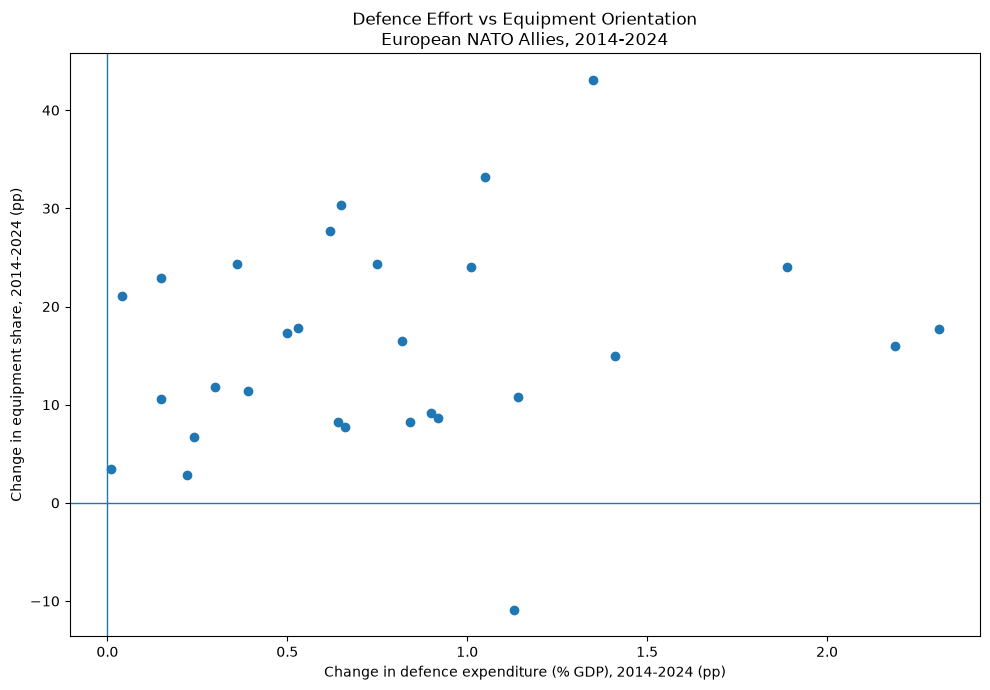

In [1698]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    strategic_change["GDP_Change_pp"],
    strategic_change["Equipment_Change_pp"]
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Change in defence expenditure (% GDP), 2014-2024 (pp)")
plt.ylabel("Change in equipment share, 2014-2024 (pp)")

plt.title(
    "Defence Effort vs Equipment Orientation\n"
    "European NATO Allies, 2014-2024"
)

plt.tight_layout()
plt.show()

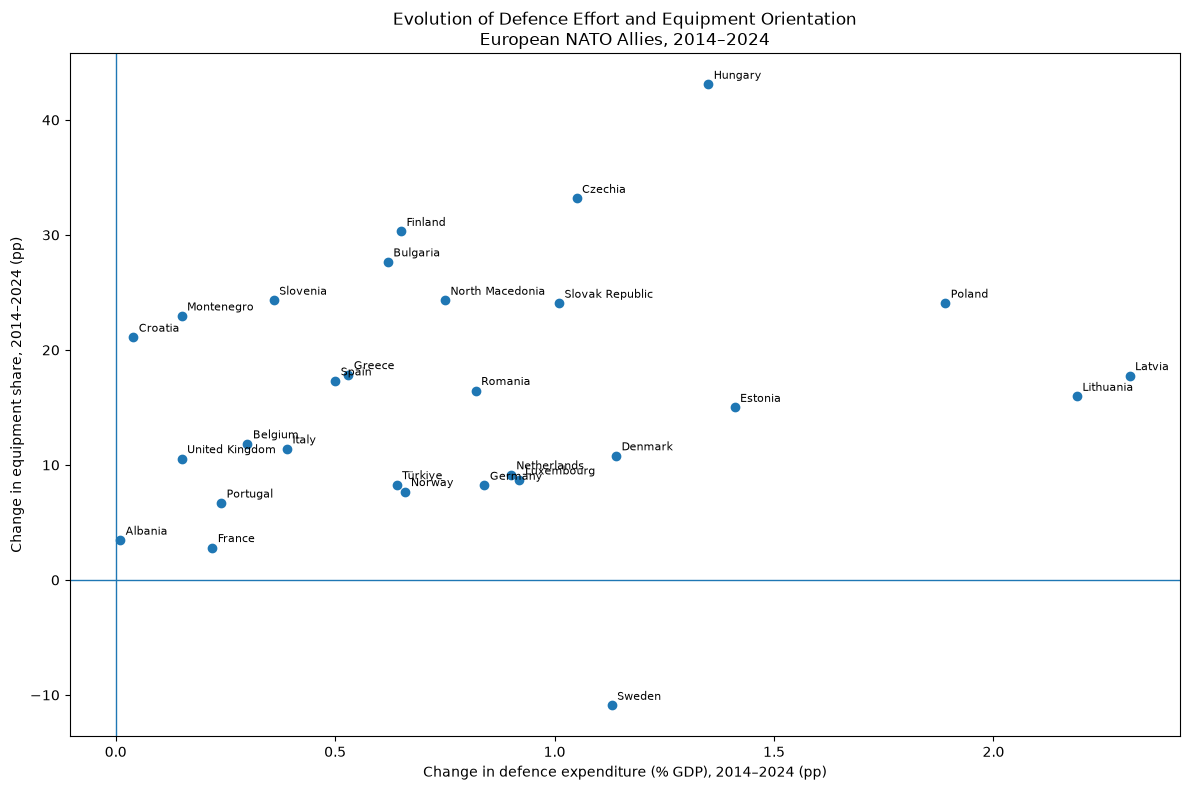

In [1699]:
plt.figure(figsize=(12, 8))

plt.scatter(
    strategic_change["GDP_Change_pp"],
    strategic_change["Equipment_Change_pp"]
)

for _, row in strategic_change.iterrows():
    plt.annotate(
        row["Country"],
        (
            row["GDP_Change_pp"],
            row["Equipment_Change_pp"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Change in defence expenditure (% GDP), 2014–2024 (pp)")
plt.ylabel("Change in equipment share, 2014–2024 (pp)")

plt.title(
    "Evolution of Defence Effort and Equipment Orientation\n"
    "European NATO Allies, 2014–2024"
)

plt.tight_layout()
plt.show()

In [1700]:
strategic_change.to_csv(
    "../data/processed/strategic_change_2014_2024.csv",
    index=False
)

In [1701]:
strategic_change.head(10)

,Country,GDP_Share_2014,GDP_Share_2024,GDP_Change_pp,Equipment_Change_pp,Personnel_Change_pp
13,Latvia,0.97,3.28,2.31,17.76,-20.10
14,Lithuania,0.88,3.07,2.19,15.96,-27.76
20,Poland,1.86,3.75,1.89,24.06,-19.22
6,Estonia,1.90,3.31,1.41,15.00,-16.64
11,Hungary,0.86,2.21,1.35,43.09,-28.18
5,Denmark,1.15,2.29,1.14,10.79,-23.12
26,Sweden,1.07,2.20,1.13,-10.91,-11.34
4,Czechia,0.94,1.99,1.05,33.17,-33.13
23,Slovak Republic,0.98,1.99,1.01,24.05,-27.26
15,Luxembourg,0.37,1.29,0.92,8.69,-28.72


### 12.1 Strategic Spending Profiles

Countries are classified according to two observable dimensions:

- Change in defence expenditure as a share of GDP.
- Change in equipment expenditure share.

The classification is descriptive and does **not** represent an assessment of military readiness or effectiveness.

In [1702]:
def classify_country(row):
    if row["GDP_Change_pp"] > 0 and row["Equipment_Change_pp"] > 0:
        return "Higher effort + More equipment"
    
    elif row["GDP_Change_pp"] > 0 and row["Equipment_Change_pp"] <= 0:
        return "Higher effort + Less equipment"
    
    elif row["GDP_Change_pp"] <= 0 and row["Equipment_Change_pp"] > 0:
        return "Lower effort + More equipment"
    
    else:
        return "Lower effort + Less equipment"


strategic_change["Strategic_Profile"] = strategic_change.apply(
    classify_country,
    axis=1
)

strategic_change["Strategic_Profile"].value_counts()

Strategic_Profile
Higher effort + More equipment    28
Higher effort + Less equipment     1
Name: count, dtype: int64

### 12.2 Defence Effort vs Equipment Orientation

The scatter plot compares changes in defence effort with changes in equipment orientation between 2014 and 2024.

Countries in the upper-right quadrant increased both:
- Defence expenditure relative to GDP.
- The share of defence expenditure allocated to equipment.

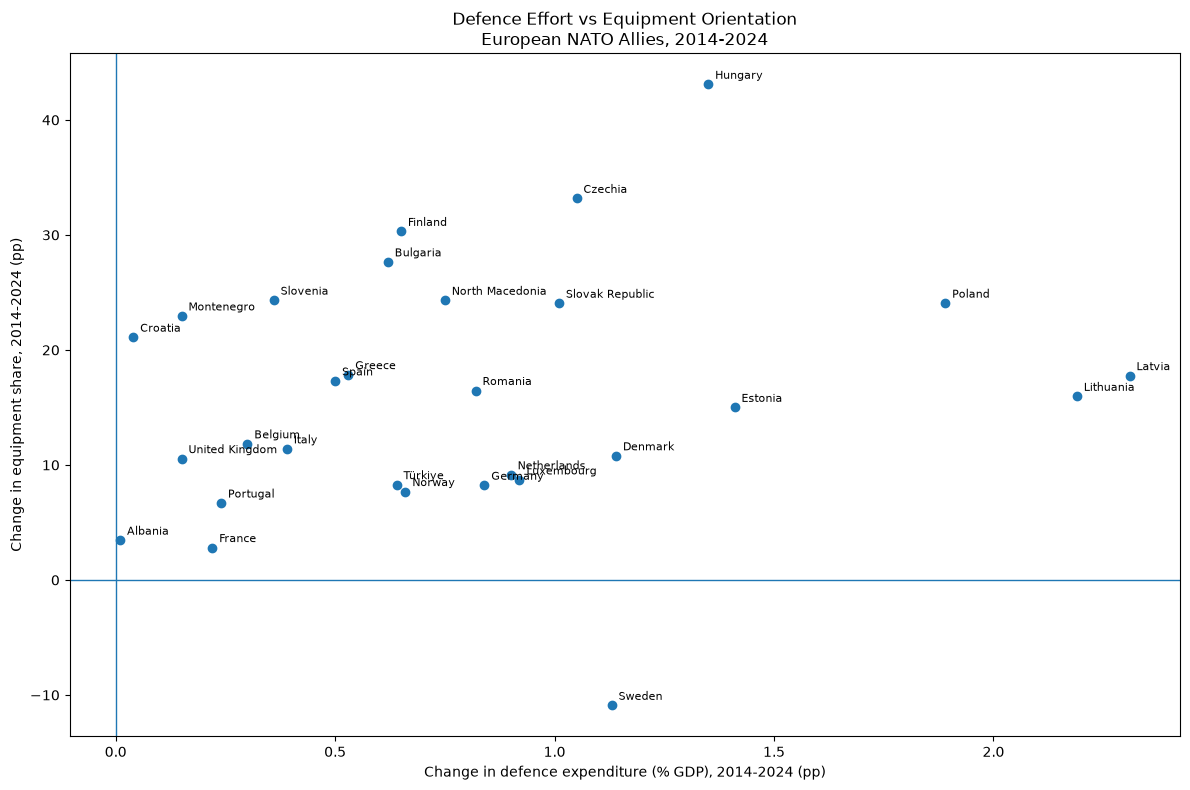

In [1703]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    strategic_change["GDP_Change_pp"],
    strategic_change["Equipment_Change_pp"]
)

for _, row in strategic_change.iterrows():
    plt.annotate(
        row["Country"],
        (
            row["GDP_Change_pp"],
            row["Equipment_Change_pp"]
        ),
        fontsize=8,
        xytext=(5, 4),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(
    "Change in defence expenditure (% GDP), 2014-2024 (pp)"
)

plt.ylabel(
    "Change in equipment share, 2014-2024 (pp)"
)

plt.title(
    "Defence Effort vs Equipment Orientation\n"
    "European NATO Allies, 2014-2024"
)

plt.tight_layout()
plt.show()

### 12.3 Relative Growth in Defence Effort

Absolute percentage-point changes are complemented with relative growth.

This identifies countries whose defence burden increased substantially compared with their own 2014 starting point.

In [1704]:
strategic_change["GDP_Relative_Growth_pct"] = (
    (
        strategic_change["GDP_Share_2024"]
        / strategic_change["GDP_Share_2014"]
    ) - 1
) * 100

In [1705]:
strategic_change[
    [
        "Country",
        "GDP_Share_2014",
        "GDP_Share_2024",
        "GDP_Change_pp",
        "GDP_Relative_Growth_pct"
    ]
].sort_values(
    "GDP_Relative_Growth_pct",
    ascending=False
).head(10)

,Country,GDP_Share_2014,GDP_Share_2024,GDP_Change_pp,GDP_Relative_Growth_pct
14,Lithuania,0.88,3.07,2.19,248.863636
15,Luxembourg,0.37,1.29,0.92,248.648649
13,Latvia,0.97,3.28,2.31,238.144330
11,Hungary,0.86,2.21,1.35,156.976744
4,Czechia,0.94,1.99,1.05,111.702128
26,Sweden,1.07,2.20,1.13,105.607477
23,Slovak Republic,0.98,1.99,1.01,103.061224
20,Poland,1.86,3.75,1.89,101.612903
5,Denmark,1.15,2.29,1.14,99.130435
17,Netherlands,1.12,2.02,0.90,80.357143


In [1706]:
strategic_change[
    strategic_change["Country"] == "Spain"
]

strategic_change_ranked = (
    strategic_change
    .sort_values("GDP_Change_pp", ascending=False)
    .reset_index(drop=True)
)

strategic_change_ranked["GDP_Change_Rank"] = (
    strategic_change_ranked.index + 1
)

strategic_change_ranked[
    strategic_change_ranked["Country"] == "Spain"
]

,Country,GDP_Share_2014,GDP_Share_2024,GDP_Change_pp,Equipment_Change_pp,Personnel_Change_pp,Strategic_Profile,GDP_Relative_Growth_pct,GDP_Change_Rank
19,Spain,0.92,1.42,0.5,17.3,-15.91,Higher effort + More equipment,54.347826,20


## 13. Defence Spending Outlook: 2024–2026

The final Python analysis compares the latest observed year (2024) with NATO estimates for 2026.

This section is treated as an **outlook rather than historical evidence**, since 2025 and 2026 figures are estimates.

The analysis examines expected changes in:
- Defence expenditure as a share of GDP
- Equipment expenditure share
- Personnel expenditure share

Where is defence spending heading?

In [1707]:
data_2026 = df_europe_master[
    df_europe_master["Year"] == 2026
][
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share",
        "Real_Annual_Change"
    ]
].copy()

data_2026 = data_2026.rename(
    columns={
        "GDP_Share": "GDP_Share_2026e",
        "Equipment_Share": "Equipment_Share_2026e",
        "Personnel_Share": "Personnel_Share_2026e",
        "Real_Annual_Change": "Real_Annual_Change_2026e"
    }
)

In [1708]:
data_2024_outlook = df_europe_master[
    df_europe_master["Year"] == 2024
][
    [
        "Country",
        "GDP_Share",
        "Equipment_Share",
        "Personnel_Share"
    ]
].copy()

data_2024_outlook = data_2024_outlook.rename(
    columns={
        "GDP_Share": "GDP_Share_2024",
        "Equipment_Share": "Equipment_Share_2024",
        "Personnel_Share": "Personnel_Share_2024"
    }
)

In [1709]:
outlook_2024_2026 = pd.merge(
    data_2024_outlook,
    data_2026,
    on="Country",
    how="inner"
)

In [1710]:
outlook_2024_2026["GDP_Change_2024_2026_pp"] = (
    outlook_2024_2026["GDP_Share_2026e"]
    - outlook_2024_2026["GDP_Share_2024"]
)

outlook_2024_2026["Equipment_Change_2024_2026_pp"] = (
    outlook_2024_2026["Equipment_Share_2026e"]
    - outlook_2024_2026["Equipment_Share_2024"]
)

In [1711]:
outlook_2024_2026.sort_values(
    "GDP_Change_2024_2026_pp",
    ascending=False
).head(10)

,Country,GDP_Share_2024,Equipment_Share_2024,Personnel_Share_2024,GDP_Share_2026e,Equipment_Share_2026e,Personnel_Share_2026e,Real_Annual_Change_2026e,GDP_Change_2024_2026_pp,Equipment_Change_2024_2026_pp
14,Lithuania,3.07,30.02,29.77,5.33,47.57,21.38,36.04,2.26,17.55
6,Estonia,3.31,37.15,21.98,5.10,40.12,18.41,32.41,1.79,2.97
13,Latvia,3.28,25.31,32.87,4.92,40.10,22.04,36.81,1.64,14.79
5,Denmark,2.29,21.78,28.15,3.49,34.65,17.69,9.44,1.20,12.87
26,Sweden,2.20,29.56,22.76,3.22,25.41,20.58,15.09,1.02,-4.15
19,Norway,2.16,28.10,29.26,3.17,17.95,20.10,1.52,1.01,-10.15
20,Poland,3.75,42.90,32.23,4.68,55.91,27.34,13.39,0.93,13.01
10,Greece,2.77,26.02,61.12,3.65,37.65,52.22,33.17,0.88,11.63
0,Albania,1.35,20.10,51.42,2.15,52.62,34.07,50.03,0.80,32.52
27,Türkiye,2.08,33.36,43.20,2.85,30.10,36.97,25.86,0.77,-3.26


### Observed vs Estimated Data

A categorical `Data_Status` field is created to distinguish historical observations from NATO estimates.

This variable will later be used in Power BI to visually differentiate observed trends from estimated values.

In [1712]:
df_master["Data_Status"] = df_master["Estimated"].map(
    {
        False: "Observed",
        True: "Estimate"
    }
)

df_master[
    ["Year", "Estimated", "Data_Status"]
].drop_duplicates().sort_values("Year")

,Year,Estimated,Data_Status
0,2014,False,Observed
33,2015,False,Observed
66,2016,False,Observed
99,2017,False,Observed
132,2018,False,Observed
165,2019,False,Observed
198,2020,False,Observed
231,2021,False,Observed
264,2022,False,Observed
297,2023,False,Observed


In [1713]:
strategic_change["GDP_Relative_Growth_pct"] = (
    (
        strategic_change["GDP_Share_2024"]
        / strategic_change["GDP_Share_2014"]
    ) - 1
) * 100

strategic_change[
    [
        "Country",
        "GDP_Share_2014",
        "GDP_Share_2024",
        "GDP_Change_pp",
        "GDP_Relative_Growth_pct",
        "Equipment_Change_pp",
        "Strategic_Profile"
    ]
].sort_values(
    "GDP_Relative_Growth_pct",
    ascending=False
).head(10)

,Country,GDP_Share_2014,GDP_Share_2024,GDP_Change_pp,GDP_Relative_Growth_pct,Equipment_Change_pp,Strategic_Profile
14,Lithuania,0.88,3.07,2.19,248.863636,15.96,Higher effort + More equipment
15,Luxembourg,0.37,1.29,0.92,248.648649,8.69,Higher effort + More equipment
13,Latvia,0.97,3.28,2.31,238.144330,17.76,Higher effort + More equipment
11,Hungary,0.86,2.21,1.35,156.976744,43.09,Higher effort + More equipment
4,Czechia,0.94,1.99,1.05,111.702128,33.17,Higher effort + More equipment
26,Sweden,1.07,2.20,1.13,105.607477,-10.91,Higher effort + Less equipment
23,Slovak Republic,0.98,1.99,1.01,103.061224,24.05,Higher effort + More equipment
20,Poland,1.86,3.75,1.89,101.612903,24.06,Higher effort + More equipment
5,Denmark,1.15,2.29,1.14,99.130435,10.79,Higher effort + More equipment
17,Netherlands,1.12,2.02,0.90,80.357143,9.14,Higher effort + More equipment


In [1714]:
df_master.to_csv(
    "../data/processed/nato_defence_master_2014_2026.csv",
    index=False
)

In [1715]:
strategic_change.to_csv(
    "../data/processed/strategic_change_2014_2024.csv",
    index=False
)

In [1716]:
outlook_2024_2026.to_csv(
    "../data/processed/outlook_2024_2026.csv",
    index=False
)

In [1717]:
import os

os.listdir("../data/processed")

['nato_defence_gdp_2014_2026.csv',
 'nato_defence_master_2014_2026.csv',
 'outlook_2024_2026.csv',
 'strategic_change_2014_2024.csv']

## 14. Outputs for Power BI

The Python pipeline produces three main analytical datasets:

**`nato_defence_master_2014_2026.csv`**  
Country-year master dataset used for time-series analysis and country exploration.

**`strategic_change_2014_2024.csv`**  
Historical transformation dataset used to compare changes in defence effort and budget composition.

**`outlook_2024_2026.csv`**  
Forward-looking dataset comparing observed 2024 values with NATO estimates for 2026.

These datasets will form the data layer of the Power BI dashboard.

---

### Methodological Note

This project uses publicly available NATO data and focuses on observable expenditure patterns.

Defence expenditure and budget composition should not be interpreted as direct measures of military capability, operational effectiveness or readiness.